# LECTURE 16
**Topic:** Multiplication and Circular Convolution; Periodic Extension of a Vector  
**Textbook References:** Sections 3.6, 3.7

---

## Key Points

- Circular convolution: $(a\circledast b)[n] = a^T P^n R b = \sum_{m=0}^{N-1}a[m]\,b[(n-m)\bmod N]$
- **DFT 8 (time product → freq convolution):** $x\odot y \leftrightarrow \frac{1}{N}X\circledast Y$
- **DFT 9 (time convolution → freq product):** $x\circledast y \leftrightarrow X\odot Y$
- **Periodic extension:** If $x$ = $M$ copies of $s$ (length $L$), then $X = M[S[0],0,\ldots,0,S[1],0,\ldots]$ (zeros between entries of $S$).


---
## Theory and Examples

### 1. Element-by-Element Product

$(x\odot y)[n] = x[n]y[n]$

### 2–3. Circular Convolution

$(a\circledast b)[n] = a^T P^n R b$, computed for $n=0:N-1$. This is also written as:
$$(a\circledast b)[n] = \sum_{m=0}^{N-1} a[m]\,b[(n-m)\bmod N]$$

**Key insight:** All convolution computations can be packed into a single matrix-vector product:
$$a\circledast b = C_b \cdot a$$
where $C_b$ is the **circulant matrix** built from $b$ (each row is a circular shift of the previous).

Circular convolution is **commutative**: $a\circledast b = b\circledast a$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def make_P(N):
    P=np.zeros((N,N)); P[0,N-1]=1
    for i in range(1,N): P[i,i-1]=1
    return P
def make_R(N):
    R=np.zeros((N,N)); R[0,0]=1
    for i in range(1,N): R[i,N-i]=1
    return R

N=4
kappa,lam,mu,nu = 1.0,2.0,-1.0,3.0
a=np.array([kappa,lam,mu,nu])
b=np.array([1.,2.,3.,-2.])

P4=make_P(N); R4=make_R(N)

# Build circulant matrix
def circulant(b):
    N=len(b)
    P=make_P(N); R=make_R(N)
    C=np.zeros((N,N))
    Rb=R@b
    for n in range(N):
        C[n,:]=np.linalg.matrix_power(P,n)@Rb
    return C

Cb=circulant(b)
print('Circulant matrix from b=[1,2,3,-2]:')
print(Cb)
print()
a_conv_b=Cb@a
print(f'a circ b = Cb @ a = {a_conv_b}')

# Verify with formula
a_conv_b_check=np.zeros(N)
for n in range(N):
    a_conv_b_check[n]=sum(a[m]*b[(n-m)%N] for m in range(N))
print(f'Formula check:       {a_conv_b_check}')
print(f'Match? {np.allclose(a_conv_b, a_conv_b_check)}')

# Verify via DFT (DFT 9)
A=np.fft.fft(a); B=np.fft.fft(b)
a_conv_b_dft=np.fft.ifft(A*B).real
print(f'Via DFT (IFFT(A*B)):  {a_conv_b_dft}')
print(f'All methods match? {np.allclose(a_conv_b, a_conv_b_dft)}')

Circulant matrix from b=[1,2,3,-2]:
[[ 1. -2.  3.  2.]
 [ 2.  1. -2.  3.]
 [ 3.  2.  1. -2.]
 [-2.  3.  2.  1.]]

a circ b = Cb @ a = [ 0. 15.  0.  5.]
Formula check:       [ 0. 15.  0.  5.]
Match? True
Via DFT (IFFT(A*B)):  [ 0. 15.  0.  5.]
All methods match? True


---
### 4. Example: 4-point Circular Convolution

$a=[\kappa,\lambda,\mu,\nu]^T$, $b=[1,2,3,-2]^T$:

$$a\circledast b = \begin{bmatrix}1&-2&3&2\\2&1&-2&3\\3&2&1&-2\\-2&3&2&1\end{bmatrix}\begin{bmatrix}\kappa\\\lambda\\\mu\\\nu\end{bmatrix} = \begin{bmatrix}\kappa-2\lambda+3\mu+2\nu\\2\kappa+\lambda-2\mu+3\nu\\3\kappa+2\lambda+\mu-2\nu\\-2\kappa+3\lambda+2\mu+\nu\end{bmatrix}$$

### 5–6. DFT Properties 8 & 9

**DFT 8:** $s=x\odot y \leftrightarrow S=\frac{1}{N}X\circledast Y$

**DFT 9:** $s=x\circledast y \leftrightarrow S=X\odot Y$ (circular convolution in time = pointwise product in frequency)

DFT 9 is derived from DFT 8 via duality.

### 7. Connection to Polynomial Multiplication

If $a=[1,-2t,3t^2,0,0,0]^T$ and $b=[2,t,-t^2,2t^3,0,0]^T$, then $a\circledast b$ corresponds to multiplying the polynomials $1-2t+3t^2$ and $2+t-t^2+2t^3$.


In [2]:
# DFT 9: circular convolution = pointwise DFT product
np.random.seed(5)
N=8
x=np.random.randn(N); y=np.random.randn(N)
X=np.fft.fft(x); Y=np.fft.fft(y)

# Circular convolution directly
circ_direct=np.array([sum(x[m]*y[(n-m)%N] for m in range(N)) for n in range(N)])
# Via DFT
circ_dft=np.fft.ifft(X*Y).real
print('DFT 9: circular conv = IFFT(X*Y):')
print(f'  Direct: {circ_direct.round(4)}')
print(f'  DFT:    {circ_dft.round(4)}')
print(f'  Match? {np.allclose(circ_direct, circ_dft)}')

# DFT 8: pointwise product = (1/N) * circular conv of DFTs
prod_direct=x*y
# DFT of product should be (1/N) * circ conv of DFTs
circ_XY=np.array([sum(X[m]*Y[(n-m)%N] for m in range(N)) for n in range(N)])
print('\nDFT 8: DFT(x.*y) = (1/N)*(X circ Y):')
print(f'  fft(x*y):       {np.fft.fft(prod_direct).round(4)}')
print(f'  (1/N)*X circ Y: {(circ_XY/N).round(4)}')
print(f'  Match? {np.allclose(np.fft.fft(prod_direct), circ_XY/N)}')

# Polynomial multiplication example
p=[1,-2,3]; q=[2,1,-1,2]
print(f'\nPolynomial mult: ({p}) * ({q})')
r_conv=np.convolve(p,q)
print(f'Direct conv: {r_conv}')
# Via zero-padded circular convolution
N_pad=len(p)+len(q)-1
P_pad=np.fft.fft(p,N_pad); Q_pad=np.fft.fft(q,N_pad)
r_dft=np.fft.ifft(P_pad*Q_pad).real.round(10)
print(f'Via DFT:     {r_dft}')
print(f'Match? {np.allclose(r_conv, r_dft)}')

DFT 9: circular conv = IFFT(X*Y):
  Direct: [-2.9683 -1.0996  1.4354 -3.5925 -2.8375  2.07   -2.1639  0.0782]
  DFT:    [-2.9683 -1.0996  1.4354 -3.5925 -2.8375  2.07   -2.1639  0.0782]
  Match? True

DFT 8: DFT(x.*y) = (1/N)*(X circ Y):
  fft(x*y):       [ 0.1878+0.j     -0.2196+5.2675j  1.4291-0.5982j  0.4638-3.5585j
 -2.8722+0.j      0.4638+3.5585j  1.4291+0.5982j -0.2196-5.2675j]
  (1/N)*X circ Y: [ 0.1878-0.j     -0.2196+5.2675j  1.4291-0.5982j  0.4638-3.5585j
 -2.8722+0.j      0.4638+3.5585j  1.4291+0.5982j -0.2196-5.2675j]
  Match? True

Polynomial mult: ([1, -2, 3]) * ([2, 1, -1, 2])
Direct conv: [ 2 -3  3  7 -7  6]
Via DFT:     [ 2. -3.  3.  7. -7.  6.]
Match? True


---
### 9–13. Periodic Extension of a Vector

**Periodic extension:** The $L$-point synthesis equation, extended to all $n\in\mathbb{Z}$, gives a periodic sequence of period $L$.

**DFT of $M$ copies of $s$:** If $x$ = $M$ copies of $s$ (length $N=ML$), then:
$$X = M\cdot[S[0],\underbrace{0,\ldots,0}_{M-1},S[1],\underbrace{0,\ldots,0}_{M-1},\ldots,S[L-1],\underbrace{0,\ldots,0}_{M-1}]^T$$

**Example:** $L=3$, $M=4$, $s=[a,b,c]^T$, $x=[a,b,c,a,b,c,a,b,c,a,b,c]^T$:
$$X=[4A,0,0,0,4B,0,0,0,4C,0,0,0]^T$$


s=[ 1.  2. -1.], L=3, M=4, N=M*L=12
S=[2. +0.j     0.5-2.5981j 0.5+2.5981j]
X (expected 4*S[k] at k=0,4,8 and 0 elsewhere):
  X=[8. +0.j     0. +0.j     0. +0.j     0. +0.j     2.-10.3923j 0. +0.j
 0. +0.j     0. +0.j     2.+10.3923j 0. +0.j     0. +0.j     0. +0.j    ]
  Expected: [8. +0.j     0. +0.j     0. +0.j     0. +0.j     2.-10.3923j 0. +0.j
 0. +0.j     0. +0.j     2.+10.3923j 0. +0.j     0. +0.j     0. +0.j    ]
  Match? True


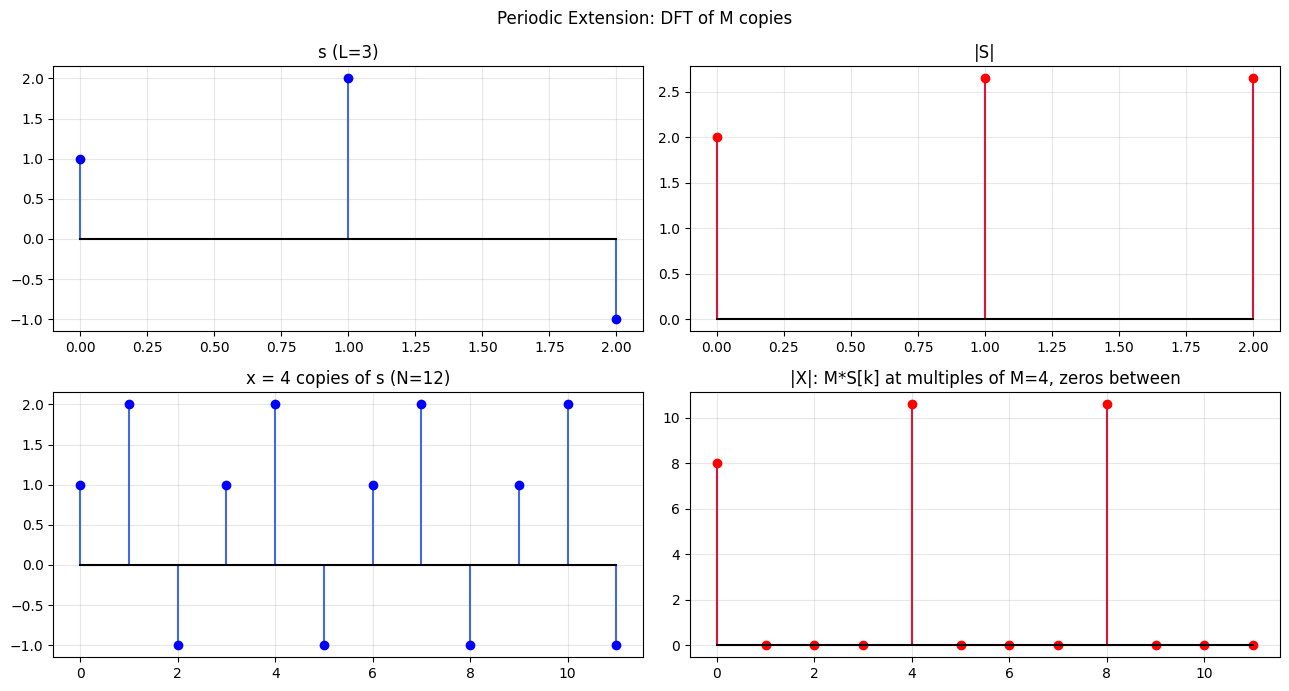

In [3]:
# Periodic extension: M copies of s
s=np.array([1.,2.,-1.]); L=len(s); M=4; N=M*L
S=np.fft.fft(s)
x=np.tile(s,M)
X=np.fft.fft(x)

print(f's={s}, L={L}, M={M}, N=M*L={N}')
print(f'S={S.round(4)}')
print(f'X (expected 4*S[k] at k=0,4,8 and 0 elsewhere):')
print(f'  X={X.round(4)}')
# Build expected
X_expected=np.zeros(N,dtype=complex)
for k in range(L):
    X_expected[k*M]=M*S[k]
print(f'  Expected: {X_expected.round(4)}')
print(f'  Match? {np.allclose(X,X_expected)}')

# Visualize
fig,axes=plt.subplots(2,2,figsize=(13,7))
axes[0][0].stem(range(L),s.real,linefmt='royalblue',markerfmt='bo',basefmt='k')
axes[0][0].set_title(f's (L={L})'); axes[0][0].grid(True,alpha=0.3)
axes[0][1].stem(range(L),np.abs(S),linefmt='crimson',markerfmt='ro',basefmt='k')
axes[0][1].set_title('|S|'); axes[0][1].grid(True,alpha=0.3)
axes[1][0].stem(range(N),x.real,linefmt='royalblue',markerfmt='bo',basefmt='k')
axes[1][0].set_title(f'x = {M} copies of s (N={N})'); axes[1][0].grid(True,alpha=0.3)
axes[1][1].stem(range(N),np.abs(X),linefmt='crimson',markerfmt='ro',basefmt='k')
axes[1][1].set_title(f'|X|: M*S[k] at multiples of M={M}, zeros between')
axes[1][1].grid(True,alpha=0.3)
plt.suptitle('Periodic Extension: DFT of M copies', fontsize=12)
plt.tight_layout(); plt.show()

---
## Summary

| DFT Property | Time Domain | Frequency Domain |
|---|---|---|
| DFT 8 | $x\odot y$ | $\frac{1}{N}X\circledast Y$ |
| DFT 9 | $x\circledast y$ | $X\odot Y$ |
| Periodic ext. | $M$ copies of $s$ | $M\cdot S$ upsampled by $M$ |

### Mistakes to Avoid
1. DFT 8 has a $1/N$ factor (time product → freq convolution). DFT 9 has NO factor (time convolution → freq product).
2. Circular convolution uses **modular** index arithmetic: $b[(n-m)\bmod N]$, NOT linear indexing.
3. Polynomial multiplication uses **linear** (not circular) convolution. Pad with zeros to avoid wraparound.
